# Multi-modal RAG

## SetUp

Install the dependencies you need to run the notebook.

In [ ]:
!sudo apt-get install -y poppler-utils tesseract-ocr libmagic-dev
%pip install accelerate>=0.26.0


: 

In [2]:
%pip install -Uq "unstructured[all-docs]" pillow lxml pillow
%pip install -Uq chromadb tiktoken
%pip install -Uq langchain langchain-community langchain-openai langchain-groq
%pip install -Uq python_dotenv


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:

# keys for the services we will use
import os
from dotenv import load_dotenv

load_dotenv()

groq_api_key = os.getenv("GROQ_API_KEY")
langchain_api_key = os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"


## Extract the data

Extract the elements of the PDF that we will be able to use in the retrieval process. These elements can be: Text, Images, Tables, etc.

### Partition PDF tables, text, and images

In [4]:
from unstructured.partition.pdf import partition_pdf


file_path = "1706.03762v7.pdf"

# Reference: https://docs.unstructured.io/open-source/core-functionality/chunking
chunks = partition_pdf(
    filename=file_path,
    extract_image_block_types=["Image"],   # Add 'Table' to list to extract image of tables
    extract_image_block_to_payload=True,   # if true, will extract base64 for API usage
    chunking_strategy="by_title",
    max_characters=3000,                   # defaults to 500
    combine_text_under_n_chars=1000,       # ensures that small chunks (under 1,000 characters) are merged together
    new_after_n_chars=6000,                #start a new chunk
)

In [5]:
set([str(type(el)) for el in chunks])

{"<class 'unstructured.documents.elements.CompositeElement'>"}

In [6]:
chunks[1].metadata.orig_elements

In [7]:
# This is what an extracted image looks like.
# It contains the base64 representation only because we set the param extract_image_block_to_payload=True

elements = chunks[3].metadata.orig_elements
chunk_images = [el for el in elements if 'Image' in str(type(el))]
chunk_images[0].to_dict()

{'type': 'Image',
 'element_id': 'f87ff764-16f2-40be-902f-6f648116aa61',
 'text': 'Output Probabilities Add & Norm Feed Forward Add & Norm Multi-Head Attention yo Add & Norm Add & Norm Feed Forward Nx | Cag Norm) Add & Norm Masked Multi-Head Multi-Head Attention Attention Lt Lt Positional Positional Encoding EQ © OY Encoding Input Output Embedding Embedding Inputs Outputs (shifted right)',
 'metadata': {'coordinates': {'points': ((545.9972222222221,
     200.00555555555542),
    (545.9972222222221, 1095.6055555555556),
    (1153.997222222222, 1095.6055555555556),
    (1153.997222222222, 200.00555555555542)),
   'system': 'PixelSpace',
   'layout_width': 1700,
   'layout_height': 2200},
  'last_modified': '2025-03-10T13:44:15',
  'filetype': 'PPM',
  'languages': ['eng'],
  'page_number': 3,
  'image_base64': '...',
  'image_mime_type': 'image/jpeg'}}

### Separate extracted elements into text, and images

In [8]:
from unstructured.documents.elements import CompositeElement

texts = []

for chunk in chunks:
    if isinstance(chunk, CompositeElement):
        if hasattr(chunk, 'text') and chunk.text.strip():
            texts.append(chunk.text)

In [9]:
def get_images_base64(chunks):
    images_b64 = []
    for chunk in chunks:
        if "CompositeElement" in str(type(chunk)):
            chunk_els = chunk.metadata.orig_elements
            for el in chunk_els:
                if "Image" in str(type(el)):
                    images_b64.append(el.metadata.image_base64)
    return images_b64

images = get_images_base64(chunks)

#### Check what the images look like

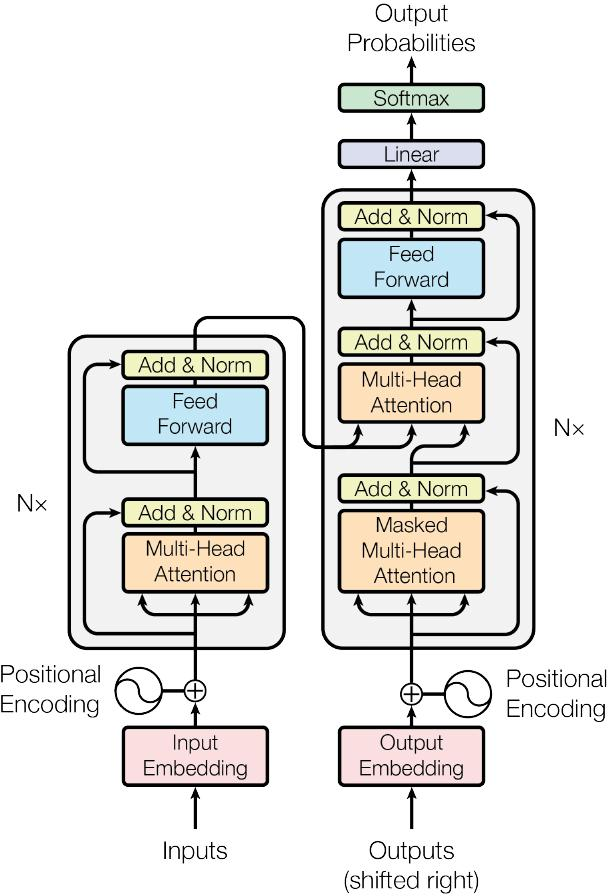

In [10]:
import base64
from IPython.display import Image, display

def display_base64_image(base64_code):
    # Decode the base64 string to binary
    image_data = base64.b64decode(base64_code)
    display(Image(data=image_data))

display_base64_image(images[0])

## Summarize the data

Create a summary of each element extracted from the PDF. This summary will be vectorized and used in the retrieval process.

### Text summaries

In [11]:
%pip install -Uq langchain-groq

Note: you may need to restart the kernel to use updated packages.


In [12]:
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [13]:
# Prompt
prompt_text = """
You are an assistant tasked with summarizing text.
Give a concise summary of text.

Respond only with the summary, no additionnal comment.
Do not start your message by saying "Here is a summary" or anything like that.
Just give the summary as it is.

text chunk: {element}

"""
prompt = ChatPromptTemplate.from_template(prompt_text)

# Summary chain
model = ChatGroq(temperature=0.5, model="llama-3.1-8b-instant")
summarize_chain = {"element": lambda x: x} | prompt | model | StrOutputParser()

In [14]:
text_summaries=summarize_chain.batch(texts, {"max_concurrency": 1})

In [15]:
text_summaries

['The paper "Attention Is All You Need" proposes a new simple network architecture, the Transformer, which uses attention mechanisms instead of recurrence and convolutions. The Transformer achieves superior results in machine translation tasks, including a 28.4 BLEU score on the WMT 2014 English-to-German task and a 41.8 BLEU score on the WMT 2014 English-to-French task, while requiring less training time.',
 'Recurrent neural networks have been established as state of the art in sequence modeling and transduction problems, but their sequential nature limits parallelization and memory constraints. Attention mechanisms have improved sequence modeling, but are often used with recurrent networks. This work proposes the Transformer, a model architecture that relies entirely on attention mechanisms to draw global dependencies, allowing for more parallelization and reaching new state of the art in translation quality.',
 'The Transformer model uses self-attention to reduce sequential computa

### Image summaries

In [16]:
!pip install -q transformers torch pillow requests

from PIL import Image
import torch
from transformers import AutoProcessor, LlavaForConditionalGeneration
import io
import base64

def process_image_from_base64(image_b64, model, processor):
    """Processes a base64 image using the Llava model and returns a cleaned summary."""

    prompt_template = """Describe the image in detail. For context,
                  the image is part of a research paper explaining the transformers
                  architecture. Be specific about graphs, such as bar plots."""

    conversation = [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": prompt_template},
                {"type": "image"},
            ],
        },
    ]
    prompt = processor.apply_chat_template(conversation, add_generation_prompt=True)

    image_data = base64.b64decode(image_b64) #3am hawila la binary
    raw_image = Image.open(io.BytesIO(image_data))

    inputs = processor(images=raw_image, text=prompt, return_tensors='pt').to(0, torch.float16)
    output = model.generate(**inputs, max_new_tokens=200, do_sample=False) # "max_new_tokens" limits the length of the output

    response = processor.decode(output[0][2:], skip_special_tokens=True) #generated output is a tensor, so "processor.decode" is used to convert it back to a readable string.


    response = response.replace(prompt_template, "").strip()
    response = response.replace("ASSISTANT:", "").strip()

    return response


model_id = "llava-hf/llava-1.5-7b-hf"
vision_model = LlavaForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.float16,

).to(0)
vision_processor = AutoProcessor.from_pretrained(model_id)



image_summaries = []


if images:
    for idx, img_b64 in enumerate(images):
        result = process_image_from_base64(img_b64, vision_model, vision_processor)
        image_summaries.append(result)


config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/70.1k [00:00<?, ?B/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/4.96G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.18G [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/1.45k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.62M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/41.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

In [17]:
image_summaries

['ER:  \n  The image is a visual representation of the transformers architecture, which is a part of a research paper. The architecture is divided into two main sections: the feed-forward network and the add-and-norm module. The feed-forward network is responsible for processing the input data, while the add-and-norm module is responsible for adding and normalizing the input data.\n\nThere are multiple graphs in the image, including a bar plot that shows the different components of the architecture. The bar plot is located on the left side of the image, and it displays the components of the feed-forward network and the add-and-norm module. The image also includes a diagram that illustrates the flow of data through the transformers architecture.',
 'ER:  \n  The image is a diagram that illustrates the transformers architecture, which is a popular deep learning model. The diagram consists of multiple layers, including a mask layer, a scale layer, and a softmax layer. The mask layer is re

In [18]:
print(image_summaries[1])

ER:  
  The image is a diagram that illustrates the transformers architecture, which is a popular deep learning model. The diagram consists of multiple layers, including a mask layer, a scale layer, and a softmax layer. The mask layer is responsible for masking the input data, while the scale layer is responsible for scaling the input data. The softmax layer is used to convert the input data into a probability distribution.

The diagram is divided into three sections, each with its own color scheme. The first section is pink, the second section is green, and the third section is purple. The diagram also includes a bar plot that shows the different layers of the transformers architecture.


## Load data and summaries to vectorstore

### Create the vectorstore

In [19]:
%pip install sentence-transformers
%pip install open-clip-torch
%pip install --upgrade --quiet  langchain-experimental

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 98.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


In [85]:
import uuid
import pickle
from langchain.vectorstores import Chroma
from langchain.storage import InMemoryStore
from langchain_core.documents import Document
from langchain.embeddings import HuggingFaceEmbeddings
from langchain.retrievers.multi_vector import MultiVectorRetriever
from langchain_experimental.open_clip import OpenCLIPEmbeddings
'''from google.colab import drive


import os
if not os.path.exists('/content/drive/MyDrive/chroma_db'):
    drive.mount('/content/drive')
else:
    print("Google Drive is already mounted.")'''


PERSIST_DIRECTORY = "chroma_db"


embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
#embedding_model = OpenCLIPEmbeddings(model_name="ViT-g-14", checkpoint="laion2b_s34b_b88k")

vectorstore = Chroma(
    collection_name="multi_modal_rag",
    embedding_function=embedding_model,
    persist_directory=PERSIST_DIRECTORY
)

try:
    with open(PERSIST_DIRECTORY + "/docstore.pkl", "rb") as f:
        store = pickle.load(f)
    print("Docstore loaded successfully!")
except FileNotFoundError:
    print("Docstore not found! Using an empty store.")
    store = InMemoryStore()  # Use empty docstore if none exists

id_key = "doc_id"

retriever = MultiVectorRetriever(
    vectorstore=vectorstore,
    docstore=store,
    id_key=id_key,
)



Docstore loaded successfully!


In [ ]:
doc_ids = [str(uuid.uuid4()) for _ in texts]
summary_texts = [
    Document(page_content=summary, metadata={id_key: doc_ids[i]}) for i, summary in enumerate(text_summaries)
]
retriever.vectorstore.add_documents(summary_texts)
retriever.docstore.mset(list(zip(doc_ids, texts)))


img_ids = [str(uuid.uuid4()) for _ in images]
summary_img = [
    Document(page_content=summary, metadata={id_key: img_ids[i]}) for i, summary in enumerate(image_summaries)
]
retriever.vectorstore.add_documents(summary_img)
retriever.docstore.mset(list(zip(img_ids, images)))

# Persist vector store and docstore
vectorstore.persist()
with open(PERSIST_DIRECTORY + "/docstore.pkl", "wb") as f:
    pickle.dump(store, f)

### Load the summaries and link the to the original data

In [86]:
#explain multihead with figures
chunks = retriever.invoke(
    "explain Scaled Dot-Product Attention with figures"
)

'''for doc in chunks:
    print(str(doc) + "\n\n" + "-" * 80)'''
chunks

 '...']

In [23]:
'''import base64
from IPython.display import Image, display

def display_base64_image(base64_code):
    # Decode the base64 string to binary
    image_data = base64.b64decode(base64_code)
    # Display the image
    display(Image(data=image_data))
display_base64_image(chunks[3])'''

'import base64\nfrom IPython.display import Image, display\n\ndef display_base64_image(base64_code):\n    # Decode the base64 string to binary\n    image_data = base64.b64decode(base64_code)\n    # Display the image\n    display(Image(data=image_data))\ndisplay_base64_image(chunks[3])'

### Check retrieval

## RAG pipeline

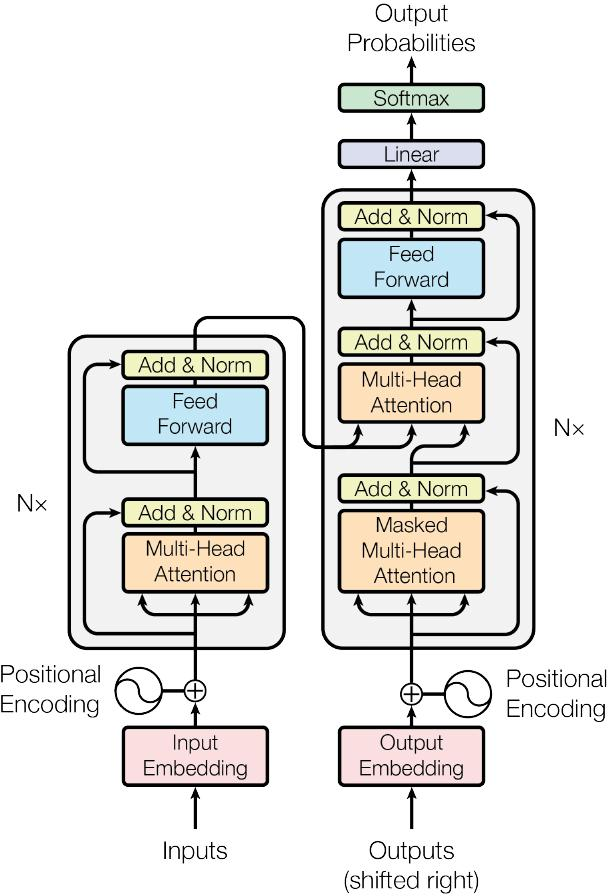

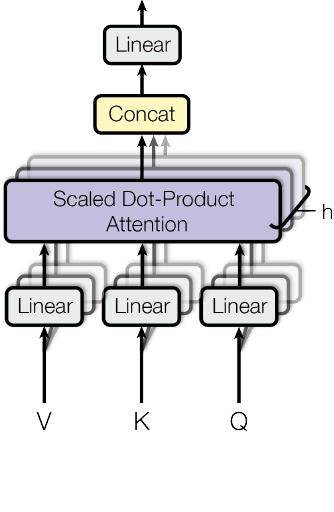

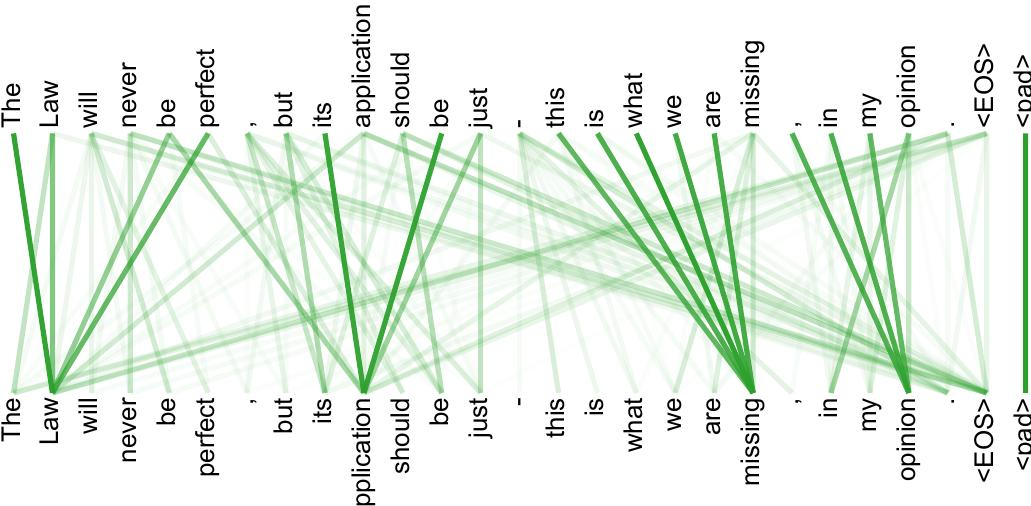


**Model Response:**
USER:  
 
 

    Answer the question based only on the following context, which can include text, tables, and the below images.
    Context: 3 Model Architecture

Most competitive neural sequence transduction models have an encoder-decoder structure [5, 2, 35]. Here, the encoder maps an input sequence of symbol representations (x1,...,xn) to a sequence of continuous representations z = (z1,...,zn). Given z, the decoder then generates an output sequence (y1,...,ym) of symbols one element at a time. At each step the model is auto-regressive [10], consuming the previously generated symbols as additional input when generating the next.

2

Output Probabilities Add & Norm Feed Forward Add & Norm Multi-Head Attention yo Add & Norm Add & Norm Feed Forward Nx | Cag Norm) Add & Norm Masked Multi-Head Multi-Head Attention Attention Lt Lt Positional Positional Encoding EQ © OY Encoding Input Output Embedding Embedding Inputs Outputs (shifted right)

Figure 1: The Transformer 

In [90]:
import base64
from io import BytesIO
from PIL import Image as PILImage
import torch
from transformers import AutoProcessor, LlavaForConditionalGeneration
from IPython.display import display

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def decode_base64_image(image_b64):
    try:
        image_data = base64.b64decode(image_b64)
        image = PILImage.open(BytesIO(image_data)).convert("RGB")
        display(image)
        return image
    except Exception as e:
        print(f"Error decoding image: {e}")
        return None


def generate_multimodal_response(context_text, user_question, image_base64_list):
    images = [decode_base64_image(img) for img in image_base64_list if img]

    prompt_template = f"""
    Answer the question based only on the following context, which can include text and the below images.
    Context: {context_text}
    Question: {user_question}
    """
#for _ in images
    conversation = [
        {
            "role": "user",
            "content": [{"type": "text", "text": prompt_template}]
                      + [{"type": "image"} for _ in images],  # Add multiple images
        },
    ]

    prompt = vision_processor.apply_chat_template(conversation, add_generation_prompt=True)
    inputs = vision_processor(images=images if images else None, text=prompt, return_tensors="pt").to(device, torch.float16)
    output_ids = vision_model.generate(**inputs, max_new_tokens=250)
    return vision_processor.tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()


# ------------------- PIPELINE EXECUTION -------------------
test_query = "Explain transfomers architecture?"

retrieved_chunks = retriever.invoke(test_query)

text_responses = []
image_base64_list = []

for doc in retrieved_chunks:
    if isinstance(doc, str) and doc.strip():
        image_base64_list.append(doc)
    elif "CompositeElement" in str(type(doc)) and hasattr(doc, "text") and doc.text.strip():
        text_responses.append(doc.text)

final_response = generate_multimodal_response(" ".join(text_responses), test_query, image_base64_list)

print("\n**Model Response:**")
print(final_response)
